# Assignment 6: Build and Evaluate Tree Models

Juan Maldonado Franco  
DDS-8555 Predictive Analysis  
Mohamed Nabeel

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
for parent in [ROOT, *ROOT.parents]:
    if (parent / "DDS-8555 - Predictive Analysis").exists():
        COURSE = parent / "DDS-8555 - Predictive Analysis"
        break
else:
    COURSE = ROOT.parents[1]
DATA = COURSE / "data"
KAGGLE = DATA / "kaggle"
SUBMISSIONS = DATA / "submissions"
RANDOM_STATE = 42
pd.set_option("display.max_columns", 80)

## Conceptual Question 1

A six-region recursive binary split can be created by first splitting X1 at t1, then splitting the left side on X2 at t2, and continuing with additional splits inside selected regions.  The matching decision tree starts with the first X1 split at the root, then branches into the later X2 and X1 cuts.  The important point is that each rectangular region corresponds to one terminal node, and each internal node corresponds to one binary decision.

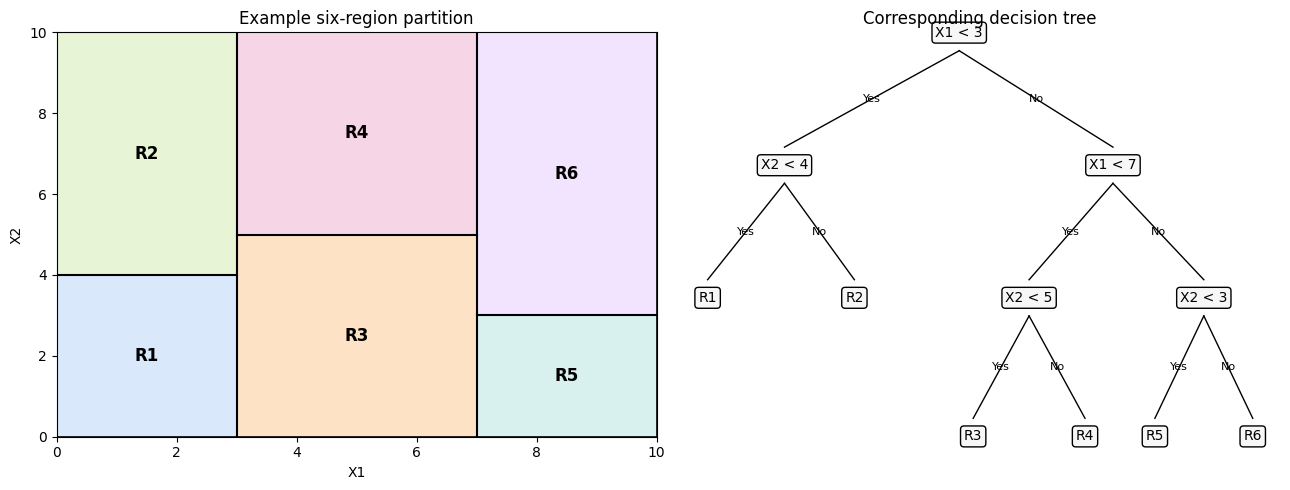

In [2]:
from matplotlib.patches import Rectangle

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Partition sketch with six terminal regions.
ax = axes[0]
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.set_title("Example six-region partition")
regions = [
    ((0, 0), 3, 4, "R1"),
    ((0, 4), 3, 6, "R2"),
    ((3, 0), 4, 5, "R3"),
    ((3, 5), 4, 5, "R4"),
    ((7, 0), 3, 3, "R5"),
    ((7, 3), 3, 7, "R6"),
]
colors = ["#d9e8fb", "#e7f4d6", "#fde2c6", "#f5d5e6", "#d8f0ee", "#f2e3ff"]
for (xy, w, h, label), color in zip(regions, colors):
    ax.add_patch(Rectangle(xy, w, h, facecolor=color, edgecolor="black", linewidth=1.2))
    ax.text(xy[0] + w / 2, xy[1] + h / 2, label, ha="center", va="center", fontsize=12, weight="bold")
ax.axvline(3, color="black", linewidth=1.5)
ax.axvline(7, color="black", linewidth=1.5)
ax.plot([0, 3], [4, 4], color="black", linewidth=1.5)
ax.plot([3, 7], [5, 5], color="black", linewidth=1.5)
ax.plot([7, 10], [3, 3], color="black", linewidth=1.5)

# Matching tree sketch.
ax = axes[1]
ax.axis("off")
ax.set_title("Corresponding decision tree")
nodes = {
    "X1 < 3": (0.50, 0.92),
    "X2 < 4": (0.25, 0.70),
    "X1 < 7": (0.72, 0.70),
    "R1": (0.14, 0.48),
    "R2": (0.35, 0.48),
    "X2 < 5": (0.60, 0.48),
    "X2 < 3": (0.85, 0.48),
    "R3": (0.52, 0.25),
    "R4": (0.68, 0.25),
    "R5": (0.78, 0.25),
    "R6": (0.92, 0.25),
}
edges = [
    ("X1 < 3", "X2 < 4", "Yes"),
    ("X1 < 3", "X1 < 7", "No"),
    ("X2 < 4", "R1", "Yes"),
    ("X2 < 4", "R2", "No"),
    ("X1 < 7", "X2 < 5", "Yes"),
    ("X1 < 7", "X2 < 3", "No"),
    ("X2 < 5", "R3", "Yes"),
    ("X2 < 5", "R4", "No"),
    ("X2 < 3", "R5", "Yes"),
    ("X2 < 3", "R6", "No"),
]
for parent, child, label in edges:
    x1, y1 = nodes[parent]
    x2, y2 = nodes[child]
    ax.plot([x1, x2], [y1 - .03, y2 + .03], color="black", linewidth=1)
    ax.text((x1 + x2) / 2, (y1 + y2) / 2, label, fontsize=8, ha="center", va="center")
for label, (x, y) in nodes.items():
    bbox = dict(boxstyle="round,pad=.25", facecolor="#f7f7f7", edgecolor="black")
    ax.text(x, y, label, ha="center", va="center", fontsize=10, bbox=bbox)
plt.tight_layout()

The left panel supplies the requested partition, and the right panel supplies the matching decision tree.  Each rectangle is one terminal region, and each internal node is one binary split.  The visual matters because recursive binary splitting is not just a list of rules; it is a way of carving feature space into rectangular prediction regions.

## Applied Question 12: Tree Methods and BART

The textbook applied exercise asks for boosting, bagging, random forests, and BART on a chosen data set.  The built-in diabetes regression data fits this part because BART is naturally implemented here as a regression model through `ISLP.bart.BART`.  RMSE and R-squared compare the flexible tree methods on the same held-out set.

### Applied Q12 Setup

The diabetes regression data is used for the textbook exercise because it lets the tree methods and BART be compared against simple regression baselines on the same continuous outcome.  The held-out split is fixed before any model is fit.

In [3]:
from ISLP.bart import BART
from sklearn.datasets import load_diabetes
from sklearn.ensemble import BaggingRegressor, GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

diabetes = load_diabetes(as_frame=True)
X_diabetes = diabetes.data
y_diabetes = diabetes.target
X_train_d, X_valid_d, y_train_d, y_valid_d = train_test_split(X_diabetes, y_diabetes, test_size=.2, random_state=RANDOM_STATE)

def regression_metrics(name, model):
    model.fit(X_train_d, y_train_d)
    pred = np.asarray(model.predict(X_valid_d)).reshape(-1)
    return {
        "textbook_model": name,
        "validation_rmse": np.sqrt(mean_squared_error(y_valid_d, pred)),
        "validation_r2": r2_score(y_valid_d, pred),
    }, model

display(pd.DataFrame({
    "setup_check": ["training_rows", "validation_rows", "predictors", "target_mean", "target_std"],
    "value": [len(X_train_d), len(X_valid_d), X_diabetes.shape[1], y_diabetes.mean(), y_diabetes.std()],
}))

,setup_check,value
0,training_rows,353.000000
1,validation_rows,89.000000
2,predictors,10.000000
3,target_mean,152.133484
4,target_std,77.093005


The setup table establishes the comparison frame.  All models use the same training and validation rows, so differences in RMSE and R-squared come from the model family rather than from different samples.  The target is continuous, which is why a linear-regression baseline is the right simple method for this part of the question.

### Applied Q12: Simple and Regularized Regression Baselines

The prompt asks how the tree methods compare to simple methods such as linear regression.  I include ordinary linear regression and RidgeCV.  RidgeCV also makes the regularized-regression requirement visible in this assignment.

In [4]:
regression_rows = []
fitted_regressors = {}
for name, model in [
    ("Linear regression baseline", LinearRegression()),
    ("RidgeCV regularized baseline", RidgeCV(alphas=[0.01, 0.1, 1, 10, 100])),
]:
    row, fitted = regression_metrics(name, model)
    if hasattr(fitted, "alpha_"):
        row["selected_alpha"] = fitted.alpha_
    regression_rows.append(row)
    fitted_regressors[name] = fitted
display(pd.DataFrame(regression_rows).sort_values("validation_rmse"))

,textbook_model,validation_rmse,validation_r2,selected_alpha
1,RidgeCV regularized baseline,53.686965,0.455982,0.01
0,Linear regression baseline,53.853446,0.452603,NaN


The baseline table answers the comparison part of Q12 directly.  If a tree method does not improve on linear regression or ridge, then the added flexibility is not justified for this data split.  RidgeCV is especially useful because it checks whether shrinkage helps the simple linear model before moving to more flexible tree methods.

### Applied Q12: Single Tree, Bagging, and Random Forest

The next table compares the core tree variance-reduction sequence: one tree, bagging, and random forest.  The models are evaluated with the same RMSE and R-squared metrics used for the baselines.

In [5]:
for name, model in [
    ("Decision tree baseline", DecisionTreeRegressor(max_depth=4, random_state=RANDOM_STATE)),
    ("Bagging", BaggingRegressor(estimator=DecisionTreeRegressor(random_state=RANDOM_STATE), n_estimators=100, random_state=RANDOM_STATE, n_jobs=1)),
    ("Random forest", RandomForestRegressor(n_estimators=200, min_samples_leaf=5, random_state=RANDOM_STATE, n_jobs=1)),
]:
    row, fitted = regression_metrics(name, model)
    regression_rows.append(row)
    fitted_regressors[name] = fitted
display(pd.DataFrame([r for r in regression_rows if r["textbook_model"] in ["Decision tree baseline", "Bagging", "Random forest"]]).sort_values("validation_rmse"))

,textbook_model,validation_rmse,validation_r2
2,Random forest,53.528279,0.459193
1,Bagging,54.505626,0.439264
0,Decision tree baseline,59.740817,0.326375


This table shows whether averaging trees improves over a single tree.  Bagging reduces variance by averaging bootstrap trees, while random forests also reduce correlation among trees by sampling predictors at each split.  The practical question is whether those variance reductions improve held-out RMSE enough to justify moving beyond a single interpretable tree.

### Applied Q12: Boosting and BART

Boosting and BART are more flexible ensemble approaches.  Boosting builds trees sequentially to correct earlier errors, while BART averages over Bayesian additive tree structures rather than treating one fitted ensemble as fixed.

In [6]:
for name, model in [
    ("Gradient boosting", GradientBoostingRegressor(random_state=RANDOM_STATE)),
    ("BART", BART(num_trees=50, num_particles=5, max_stages=100, ndraw=20, burnin=20, random_state=RANDOM_STATE, n_jobs=1)),
]:
    row, fitted = regression_metrics(name, model)
    regression_rows.append(row)
    fitted_regressors[name] = fitted
display(pd.DataFrame([r for r in regression_rows if r["textbook_model"] in ["Gradient boosting", "BART"]]).sort_values("validation_rmse"))

,textbook_model,validation_rmse,validation_r2
1,BART,51.833426,0.492898
0,Gradient boosting,53.837131,0.452934


The boosting and BART table completes the required tree-family comparison.  BART is important here because it is not just another random forest; it uses a Bayesian additive-tree framework and therefore gives a different way to average flexible tree structures (Chipman et al., 2010).

### Applied Q12: Full Regression Comparison

The final Q12 table puts all models together so the tree methods can be compared directly with the simple and regularized baselines.

In [7]:
tree_regression_results = pd.DataFrame(regression_rows).sort_values("validation_rmse")
display(tree_regression_results)
best_tree_regression = tree_regression_results.iloc[0]["textbook_model"]
display(pd.DataFrame({
    "part": ["Applied Question 12"],
    "best_validation_model": [best_tree_regression],
    "baseline_comparison": ["Tree and BART results are compared directly with linear regression and RidgeCV."],
}))

,textbook_model,validation_rmse,validation_r2,selected_alpha
6,BART,51.833426,0.492898,NaN
4,Random forest,53.528279,0.459193,NaN
1,RidgeCV regularized baseline,53.686965,0.455982,0.01
5,Gradient boosting,53.837131,0.452934,NaN
0,Linear regression baseline,53.853446,0.452603,NaN
3,Bagging,54.505626,0.439264,NaN
2,Decision tree baseline,59.740817,0.326375,NaN


,part,best_validation_model,baseline_comparison
0,Applied Question 12,BART,Tree and BART results are compared directly wi...


The full comparison answers the missing part of the textbook prompt.  The best held-out RMSE identifies the strongest model on this split, but the linear and ridge baselines determine whether the tree methods actually earned their complexity.  This keeps the conclusion grounded in prediction evidence rather than assuming tree methods must be better because they are more flexible.

## Kaggle Obesity Tree Submissions

The Kaggle portion requires four tree-based classification submissions on the Obesity data.  This section remains separate from the BART regression comparison because the competition target is multiclass classification.  A shared preprocessing object and stratified validation split keep the four models on the same observations.

In [8]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import BaggingClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

obesity_raw = pd.read_csv(KAGGLE / "playground-series-s4e2" / "train.csv")
obesity_test_raw = pd.read_csv(KAGGLE / "playground-series-s4e2" / "test.csv")
target_col = "NObeyesdad"
duplicate_ids = int(obesity_raw["id"].duplicated().sum()) if "id" in obesity_raw else 0
duplicate_test_ids = int(obesity_test_raw["id"].duplicated().sum()) if "id" in obesity_test_raw else 0
missing_by_column = obesity_raw.isna().sum()
missing_by_column_test = obesity_test_raw.isna().sum()
blank_object_values = int(sum((obesity_raw[c].astype(str).str.strip() == "").sum() for c in obesity_raw.select_dtypes(include=["object", "string"]).columns))
blank_object_values_test = int(sum((obesity_test_raw[c].astype(str).str.strip() == "").sum() for c in obesity_test_raw.select_dtypes(include=["object", "string"]).columns))
infinite_numeric = int(np.isinf(obesity_raw.select_dtypes(include=np.number)).sum().sum())
infinite_numeric_test = int(np.isinf(obesity_test_raw.select_dtypes(include=np.number)).sum().sum())
display(pd.DataFrame({
    "quality_check": ["train_rows", "test_rows", "duplicate_train_ids", "duplicate_test_ids", "train_total_missing_values", "test_total_missing_values", "train_blank_object_values", "test_blank_object_values", "train_infinite_numeric_values", "test_infinite_numeric_values", "target_missing"],
    "value": [len(obesity_raw), len(obesity_test_raw), duplicate_ids, duplicate_test_ids, int(missing_by_column.sum()), int(missing_by_column_test.sum()), blank_object_values, blank_object_values_test, infinite_numeric, infinite_numeric_test, int(obesity_raw[target_col].isna().sum())],
}))

def clean_obesity_frame(frame, *, has_target):
    cleaned = frame.copy()
    if has_target and cleaned["id"].duplicated().any():
        cleaned = cleaned.drop_duplicates(subset=["id"], keep="first")
    cleaned = cleaned.replace([np.inf, -np.inf], np.nan)
    for col in cleaned.select_dtypes(include=["object", "string"]).columns:
        cleaned[col] = cleaned[col].astype("string").str.strip().replace("", pd.NA)
    if has_target and cleaned[target_col].isna().any():
        cleaned = cleaned.dropna(subset=[target_col])
    return cleaned

obesity = clean_obesity_frame(obesity_raw, has_target=True)
obesity_test = clean_obesity_frame(obesity_test_raw, has_target=False)
display(obesity.isna().sum().rename("train_missing_after_cleaning_flags").to_frame().query("train_missing_after_cleaning_flags > 0"))
display(obesity_test.isna().sum().rename("test_missing_after_cleaning_flags").to_frame().query("test_missing_after_cleaning_flags > 0"))

X = obesity.drop(columns=["NObeyesdad"])
y = obesity["NObeyesdad"]
display(y.value_counts(normalize=True).rename("class_share").to_frame())
cat = X.select_dtypes(include=["object", "string"]).columns.tolist()
num = [c for c in X.columns if c not in cat + ["id"]]
cat_pipe = Pipeline([("impute", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))])
num_pipe = Pipeline([("impute", SimpleImputer(strategy="median"))])
pre = ColumnTransformer([("cat", cat_pipe, cat), ("num", num_pipe, num)])
cat_pipe_dense = Pipeline([("impute", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])
num_pipe_scaled = Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())])
pre_logit = ColumnTransformer([("cat", cat_pipe_dense, cat), ("num", num_pipe_scaled, num)], sparse_threshold=0)
X_train, X_valid, y_train, y_valid = train_test_split(X.drop(columns=["id"]), y, test_size=.2, stratify=y, random_state=RANDOM_STATE)
X_model_full = X.drop(columns=["id"])
X_test_submission = obesity_test.drop(columns=["id"])
base_tree = DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE)
display(pd.DataFrame({
    "setup_check": ["training_rows", "validation_rows", "test_rows_for_submission", "class_count", "categorical_predictors", "numeric_predictors"],
        "value": [len(X_train), len(X_valid), len(X_test_submission), y.nunique(), len(cat), len(num)],
}))

def write_obesity_tree_submission(model, filename):
    final_model = clone(model)
    final_model.fit(X_model_full, y)
    predictions = final_model.predict(X_test_submission)
    submission = pd.DataFrame({"id": obesity_test["id"], target_col: predictions})
    submission.to_csv(SUBMISSIONS / filename, index=False)
    return filename, len(submission)

,quality_check,value
0,train_rows,20758
1,test_rows,13840
2,duplicate_train_ids,0
3,duplicate_test_ids,0
4,train_total_missing_values,0
5,test_total_missing_values,0
6,train_blank_object_values,0
7,test_blank_object_values,0
8,train_infinite_numeric_values,0
9,test_infinite_numeric_values,0


,train_missing_after_cleaning_flags


,test_missing_after_cleaning_flags


,class_share
NObeyesdad,
Obesity_Type_III,0.194913
Obesity_Type_II,0.15647
Normal_Weight,0.148473
Obesity_Type_I,0.140187
Insufficient_Weight,0.121544
Overweight_Level_II,0.121495
Overweight_Level_I,0.116919


,setup_check,value
0,training_rows,16606
1,validation_rows,4152
2,test_rows_for_submission,13840
3,class_count,7
4,categorical_predictors,8
5,numeric_predictors,8


### Kaggle Regularized Baseline: Multinomial Logistic Regression

Before fitting the tree models, I include a tuned-C multinomial logistic baseline.  This satisfies the regularized-regression requirement and gives the tree models a non-tree benchmark on the same validation split.

In [9]:
logit_c_rows = []
for C in [.05, .1, .25, .5, 1, 2, 5, 10]:
    candidate = Pipeline([
        ("pre", pre_logit),
        ("model", LogisticRegression(max_iter=3000, C=C)),
    ])
    candidate.fit(X_train, y_train)
    pred = candidate.predict(X_valid)
    logit_c_rows.append({
        "C": C,
        "validation_accuracy": accuracy_score(y_valid, pred),
        "balanced_accuracy": balanced_accuracy_score(y_valid, pred),
    })
logit_c_table = pd.DataFrame(logit_c_rows).sort_values(["validation_accuracy", "balanced_accuracy"], ascending=False)
display(logit_c_table)
best_logit_c = float(logit_c_table.iloc[0]["C"])
logit_baseline = Pipeline([
    ("pre", pre_logit),
    ("model", LogisticRegression(max_iter=3000, C=best_logit_c)),
])
logit_baseline.fit(X_train, y_train)
logit_pred = logit_baseline.predict(X_valid)
logit_accuracy = accuracy_score(y_valid, logit_pred)
logit_balanced = balanced_accuracy_score(y_valid, logit_pred)
display(pd.DataFrame({
    "model": ["Regularized multinomial logistic baseline"],
    "selected_C": [best_logit_c],
    "validation_accuracy": [logit_accuracy],
    "balanced_accuracy": [logit_balanced],
}))

,C,validation_accuracy,balanced_accuracy
7,10.00,0.873314,0.860028
5,2.00,0.871146,0.857850
6,5.00,0.870906,0.857480
4,1.00,0.868738,0.854949
3,0.50,0.865366,0.851134
2,0.25,0.859345,0.844542
1,0.10,0.841763,0.825046
0,0.05,0.820568,0.801713


,model,selected_C,validation_accuracy,balanced_accuracy
0,Regularized multinomial logistic baseline,10.0,0.873314,0.860028


The logistic C table makes regularization explicit.  Smaller C values impose stronger L2 shrinkage, while larger C values allow a more flexible linear decision boundary.  This model is not one of the four required tree submissions, but it is important because it shows whether tree flexibility is improving on a regularized linear baseline.

### Kaggle Model 1: Decision Tree

The first Kaggle tree model is a single decision tree.  It gives the clearest baseline because the prediction is driven by one sequence of splits.

In [10]:
tree_model = Pipeline([
    ("pre", pre),
    ("model", DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE)),
])
tree_model.fit(X_train, y_train)
tree_train_pred = tree_model.predict(X_train)
tree_pred = tree_model.predict(X_valid)
tree_train_accuracy = accuracy_score(y_train, tree_train_pred)
tree_accuracy = accuracy_score(y_valid, tree_pred)
tree_balanced = balanced_accuracy_score(y_valid, tree_pred)
tree_submission_file, tree_submission_rows = write_obesity_tree_submission(tree_model, "A6_decision_tree_playground_series_s4e2.csv")
display(pd.DataFrame({
    "model": ["Decision tree"],
    "train_accuracy": [tree_train_accuracy],
    "validation_accuracy": [tree_accuracy],
    "balanced_accuracy": [tree_balanced],
    "generalization_gap": [tree_train_accuracy - tree_accuracy],
    "submission_file": [tree_submission_file],
    "submission_rows": [tree_submission_rows],
}))

,model,train_accuracy,validation_accuracy,balanced_accuracy,generalization_gap,submission_file,submission_rows
0,Decision tree,0.893171,0.869461,0.856238,0.023711,A6_decision_tree_playground_series_s4e2.csv,13840


The single tree is useful because it is interpretable, but its role is mainly as a baseline.  A large train-validation gap would signal that one tree is adapting too closely to the training split.  Even when the gap is moderate, a single tree is more sensitive to small data changes than the ensemble models that follow.

### Kaggle Model 2: Bagging

The second Kaggle tree model is bagging.  It keeps the decision-tree base learner but averages many bootstrap trees to reduce variance.

In [11]:
bagging_model = Pipeline([
    ("pre", pre),
    ("model", BaggingClassifier(estimator=base_tree, n_estimators=80, random_state=RANDOM_STATE, n_jobs=1)),
])
bagging_model.fit(X_train, y_train)
bagging_train_pred = bagging_model.predict(X_train)
bagging_pred = bagging_model.predict(X_valid)
bagging_train_accuracy = accuracy_score(y_train, bagging_train_pred)
bagging_accuracy = accuracy_score(y_valid, bagging_pred)
bagging_balanced = balanced_accuracy_score(y_valid, bagging_pred)
bagging_submission_file, bagging_submission_rows = write_obesity_tree_submission(bagging_model, "A6_bagging_playground_series_s4e2.csv")
display(pd.DataFrame({
    "model": ["Bagging"],
    "train_accuracy": [bagging_train_accuracy],
    "validation_accuracy": [bagging_accuracy],
    "balanced_accuracy": [bagging_balanced],
    "generalization_gap": [bagging_train_accuracy - bagging_accuracy],
    "submission_file": [bagging_submission_file],
    "submission_rows": [bagging_submission_rows],
}))

,model,train_accuracy,validation_accuracy,balanced_accuracy,generalization_gap,submission_file,submission_rows
0,Bagging,0.902565,0.888006,0.875682,0.01456,A6_bagging_playground_series_s4e2.csv,13840


Bagging improves the research story because it directly tests whether the instability of a single tree is hurting performance.  If validation accuracy improves while the gap stays controlled, the improvement is evidence that averaging many trees is reducing variance rather than only memorizing the training data (Breiman, 1996).

### Kaggle Model 3: Random Forest

The third Kaggle tree model is a random forest.  It extends bagging by adding feature randomness, which lowers correlation among the trees being averaged.

In [12]:
rf_model = Pipeline([
    ("pre", pre),
    ("model", RandomForestClassifier(n_estimators=150, max_depth=12, random_state=RANDOM_STATE, n_jobs=1)),
])
rf_model.fit(X_train, y_train)
rf_train_pred = rf_model.predict(X_train)
rf_pred = rf_model.predict(X_valid)
rf_train_accuracy = accuracy_score(y_train, rf_train_pred)
rf_accuracy = accuracy_score(y_valid, rf_pred)
rf_balanced = balanced_accuracy_score(y_valid, rf_pred)
rf_submission_file, rf_submission_rows = write_obesity_tree_submission(rf_model, "A6_random_forest_playground_series_s4e2.csv")
rf_feature_names = rf_model.named_steps["pre"].get_feature_names_out()
rf_importance = pd.DataFrame({
    "feature": rf_feature_names,
    "importance": rf_model.named_steps["model"].feature_importances_,
}).sort_values("importance", ascending=False).head(12)
display(pd.DataFrame({
    "model": ["Random forest"],
    "train_accuracy": [rf_train_accuracy],
    "validation_accuracy": [rf_accuracy],
    "balanced_accuracy": [rf_balanced],
    "generalization_gap": [rf_train_accuracy - rf_accuracy],
    "submission_file": [rf_submission_file],
    "submission_rows": [rf_submission_rows],
}))
display(rf_importance)

,model,train_accuracy,validation_accuracy,balanced_accuracy,generalization_gap,submission_file,submission_rows
0,Random forest,0.952668,0.890173,0.877267,0.062494,A6_random_forest_playground_series_s4e2.csv,13840


,feature,importance
24,num__Weight,0.359729
25,num__FCVC,0.100077
22,num__Age,0.093350
23,num__Height,0.074393
0,cat__Gender_Female,0.045141
29,num__TUE,0.045004
27,num__CH2O,0.038828
1,cat__Gender_Male,0.035775
26,num__NCP,0.027150
28,num__FAF,0.025871


The random forest is the strongest variance-reduction comparison because it changes not only the sampled rows but also the predictors considered at each split.  The feature-importance table gives the model a substantive interpretation and shows which encoded health and measurement variables are driving the classification result (Breiman, 2001).

### Kaggle Model 4: Gradient Boosting

The fourth Kaggle tree model is gradient boosting.  It builds trees sequentially, so it is designed to correct errors left by earlier trees rather than average trees fit independently.

In [13]:
gb_model = Pipeline([
    ("pre", pre),
    ("model", GradientBoostingClassifier(random_state=RANDOM_STATE)),
])
gb_model.fit(X_train, y_train)
gb_train_pred = gb_model.predict(X_train)
gb_pred = gb_model.predict(X_valid)
gb_train_accuracy = accuracy_score(y_train, gb_train_pred)
gb_accuracy = accuracy_score(y_valid, gb_pred)
gb_balanced = balanced_accuracy_score(y_valid, gb_pred)
gb_submission_file, gb_submission_rows = write_obesity_tree_submission(gb_model, "A6_gradient_boosting_playground_series_s4e2.csv")
gb_feature_names = gb_model.named_steps["pre"].get_feature_names_out()
gb_importance = pd.DataFrame({
    "feature": gb_feature_names,
    "importance": gb_model.named_steps["model"].feature_importances_,
}).sort_values("importance", ascending=False).head(12)
display(pd.DataFrame({
    "model": ["Gradient boosting"],
    "train_accuracy": [gb_train_accuracy],
    "validation_accuracy": [gb_accuracy],
    "balanced_accuracy": [gb_balanced],
    "generalization_gap": [gb_train_accuracy - gb_accuracy],
    "submission_file": [gb_submission_file],
    "submission_rows": [gb_submission_rows],
}))
display(gb_importance)

,model,train_accuracy,validation_accuracy,balanced_accuracy,generalization_gap,submission_file,submission_rows
0,Gradient boosting,0.921233,0.905347,0.894882,0.015886,A6_gradient_boosting_playground_series_s4e2.csv,13840


,feature,importance
24,num__Weight,0.608735
25,num__FCVC,0.111034
23,num__Height,0.072169
1,cat__Gender_Male,0.049671
0,cat__Gender_Female,0.048556
22,num__Age,0.036326
27,num__CH2O,0.016228
16,cat__CALC_no,0.013646
26,num__NCP,0.011562
29,num__TUE,0.007041


Gradient boosting is the strongest recorded Kaggle submission in this assignment.  The interpretation is not simply that it has a higher score; the sequential fitting process is better matched to a multiclass problem where difficult boundary cases remain after the first trees are fit (Friedman, 2001).

In [14]:
kaggle_a6_comparison = pd.DataFrame([
    {"model": "Regularized logistic baseline", "train_accuracy": np.nan, "validation_accuracy": logit_accuracy, "balanced_accuracy": logit_balanced, "generalization_gap": np.nan, "submission_file": ""},
    {"model": "Decision tree", "train_accuracy": tree_train_accuracy, "validation_accuracy": tree_accuracy, "balanced_accuracy": tree_balanced, "generalization_gap": tree_train_accuracy - tree_accuracy, "submission_file": tree_submission_file},
    {"model": "Bagging", "train_accuracy": bagging_train_accuracy, "validation_accuracy": bagging_accuracy, "balanced_accuracy": bagging_balanced, "generalization_gap": bagging_train_accuracy - bagging_accuracy, "submission_file": bagging_submission_file},
    {"model": "Random forest", "train_accuracy": rf_train_accuracy, "validation_accuracy": rf_accuracy, "balanced_accuracy": rf_balanced, "generalization_gap": rf_train_accuracy - rf_accuracy, "submission_file": rf_submission_file},
    {"model": "Gradient boosting", "train_accuracy": gb_train_accuracy, "validation_accuracy": gb_accuracy, "balanced_accuracy": gb_balanced, "generalization_gap": gb_train_accuracy - gb_accuracy, "submission_file": gb_submission_file},
]).sort_values("validation_accuracy", ascending=False)
display(kaggle_a6_comparison)
tree_only_comparison = kaggle_a6_comparison[kaggle_a6_comparison["submission_file"] != ""].copy()
best_tree_name = tree_only_comparison.iloc[0]["model"]
best_tree_pred = {"Decision tree": tree_pred, "Bagging": bagging_pred, "Random forest": rf_pred, "Gradient boosting": gb_pred}[best_tree_name]

,model,train_accuracy,validation_accuracy,balanced_accuracy,generalization_gap,submission_file
4,Gradient boosting,0.921233,0.905347,0.894882,0.015886,A6_gradient_boosting_playground_series_s4e2.csv
3,Random forest,0.952668,0.890173,0.877267,0.062494,A6_random_forest_playground_series_s4e2.csv
2,Bagging,0.902565,0.888006,0.875682,0.014560,A6_bagging_playground_series_s4e2.csv
0,Regularized logistic baseline,NaN,0.873314,0.860028,NaN,
1,Decision tree,0.893171,0.869461,0.856238,0.023711,A6_decision_tree_playground_series_s4e2.csv


The comparison table places the four Kaggle submissions and the regularized logistic baseline on the same validation split.  The single tree anchors interpretability, bagging and random forests test variance reduction, and gradient boosting tests sequential error correction.  The logistic row answers a different question: whether the added tree flexibility improves on a regularized linear classifier.

### Kaggle Best Tree Confusion Matrix

The confusion matrix for the best validation tree model shows which obesity categories remain hardest to separate.  This deserves its own output because multiclass accuracy can hide class-specific mistakes.

In [15]:
best_tree_confusion = pd.DataFrame(
    confusion_matrix(y_valid, best_tree_pred, labels=tree_model.classes_),
    index=[f"Actual {label}" for label in tree_model.classes_],
    columns=[f"Pred {label}" for label in tree_model.classes_],
)
display(best_tree_confusion)

,Pred Insufficient_Weight,Pred Normal_Weight,Pred Obesity_Type_I,Pred Obesity_Type_II,Pred Obesity_Type_III,Pred Overweight_Level_I,Pred Overweight_Level_II
Actual Insufficient_Weight,482,22,0,0,0,1,0
Actual Normal_Weight,32,547,1,0,0,29,8
Actual Obesity_Type_I,1,3,523,14,3,7,31
Actual Obesity_Type_II,1,0,20,628,0,0,1
Actual Obesity_Type_III,0,0,2,1,806,0,0
Actual Overweight_Level_I,1,48,9,0,0,365,62
Actual Overweight_Level_II,0,7,41,3,0,45,408


The confusion matrix moves the interpretation beyond a single accuracy value.  Misclassifications between adjacent obesity categories are more understandable than errors across distant categories, because the competition labels represent ordered body-size groups even though the classifier treats them as nominal classes.

### Kaggle Diagnostics: Feature Importance Comparison

Random forests and gradient boosting both produce feature-importance tables.  Comparing their top features checks whether the two strongest ensemble families are using similar signals or relying on different parts of the data.

In [16]:
rf_top = rf_importance.assign(source_model="Random forest")
gb_top = gb_importance.assign(source_model="Gradient boosting")
importance_comparison = pd.concat([rf_top, gb_top], ignore_index=True)
display(importance_comparison[["source_model", "feature", "importance"]])

,source_model,feature,importance
0,Random forest,num__Weight,0.359729
1,Random forest,num__FCVC,0.100077
2,Random forest,num__Age,0.093350
3,Random forest,num__Height,0.074393
4,Random forest,cat__Gender_Female,0.045141
5,Random forest,num__TUE,0.045004
6,Random forest,num__CH2O,0.038828
7,Random forest,cat__Gender_Male,0.035775
8,Random forest,num__NCP,0.027150
9,Random forest,num__FAF,0.025871


The feature-importance comparison is an assumption and interpretation check for the tree models.  If both ensembles emphasize similar encoded measurements and behavior variables, the finding is more stable than if each model depends on unrelated predictors.  The importances are not causal effects, but they show which variables are doing most of the classification work.

### Kaggle Diagnostics: Per-Class Error

The next table reports validation recall by class for the best tree model.  This is a direct check on whether the model is strong across classes or mainly accurate for the largest/easiest categories.

In [17]:
best_tree_classes = list(tree_model.classes_)
cm = confusion_matrix(y_valid, best_tree_pred, labels=best_tree_classes)
per_class_error = pd.DataFrame({
    "class": best_tree_classes,
    "support": cm.sum(axis=1),
    "correct": np.diag(cm),
})
per_class_error["recall"] = per_class_error["correct"] / per_class_error["support"]
per_class_error["error_rate"] = 1 - per_class_error["recall"]
display(per_class_error.sort_values("error_rate", ascending=False))

,class,support,correct,recall,error_rate
5,Overweight_Level_I,485,365,0.752577,0.247423
6,Overweight_Level_II,504,408,0.809524,0.190476
1,Normal_Weight,617,547,0.886548,0.113452
2,Obesity_Type_I,582,523,0.898625,0.101375
0,Insufficient_Weight,505,482,0.954455,0.045545
3,Obesity_Type_II,650,628,0.966154,0.033846
4,Obesity_Type_III,809,806,0.996292,0.003708


The per-class error table is the most direct diagnostic for the Obesity competition.  It shows whether performance is uneven across body-size categories and protects the analysis from treating overall accuracy as the whole story.  Classes with high error rates are the ones that need closer review before the model is used outside the competition context.

### Kaggle Submission Evidence: Leaderboard Status

The status table is read from the Kaggle CLI status export and filtered to the four Assignment 6 tree files.  When a file has multiple submission rows, the newest row is retained.

In [18]:
import re

a6_files = [
    "A6_decision_tree_playground_series_s4e2.csv",
    "A6_bagging_playground_series_s4e2.csv",
    "A6_random_forest_playground_series_s4e2.csv",
    "A6_gradient_boosting_playground_series_s4e2.csv",
]
status_path = SUBMISSIONS / "kaggle_submission_status_playground-series-s4e2.txt"
for encoding in ("utf-16", "utf-8"):
    try:
        text = status_path.read_text(encoding=encoding)
        break
    except UnicodeError:
        continue

records = []
seen_files = set()
for line in text.splitlines():
    parts = re.split(r"\s{2,}", line.strip())
    if len(parts) >= 7 and parts[0].isdigit() and parts[1] in a6_files and parts[1] not in seen_files:
        seen_files.add(parts[1])
        records.append({
            "ref": parts[0],
            "fileName": parts[1],
            "date": parts[2],
            "description": parts[3],
            "status": parts[4],
            "publicScore": parts[5],
            "privateScore": parts[6],
        })
display(pd.DataFrame(records))

,ref,fileName,date,description,status,publicScore,privateScore
0,53578339,A6_gradient_boosting_playground_series_s4e2.csv,2026-06-11 18:34:59.007000,A6 gradient boosting regenerated from notebook,SubmissionStatus.COMPLETE,0.90462,0.90236
1,53578332,A6_random_forest_playground_series_s4e2.csv,2026-06-11 18:34:50.173000,A6 random forest regenerated from notebook,SubmissionStatus.COMPLETE,0.88656,0.88782
2,53578326,A6_bagging_playground_series_s4e2.csv,2026-06-11 18:34:38.397000,A6 bagging regenerated from notebook,SubmissionStatus.COMPLETE,0.88439,0.88502
3,53578322,A6_decision_tree_playground_series_s4e2.csv,2026-06-11 18:34:30.120000,A6 decision tree regenerated from notebook,SubmissionStatus.COMPLETE,0.87319,0.87536


The leaderboard evidence confirms that the four required tree submissions were received and scored.  The notebook now also writes the four CSV files, so the evidence is tied to the displayed modeling code.

### Kaggle Submission Evidence: Local Files and GitHub

The local-file check verifies that the notebook-generated CSV files exist, and the GitHub table records the public code artifact path.

In [19]:
display(pd.DataFrame({
    "submission_file": a6_files,
    "exists_locally": [(SUBMISSIONS / file).exists() for file in a6_files],
    "row_count": [pd.read_csv(SUBMISSIONS / file).shape[0] if (SUBMISSIONS / file).exists() else None for file in a6_files],
}))
display(pd.DataFrame({
    "evidence": ["Public GitHub repository", "Notebook path in repository"],
    "value": [
        "https://github.com/maldo81/dds-8555-predictive-analysis",
        "Week 6/Assignment 6/MaldonadoJDDS8555-6.ipynb",
    ],
}))

,submission_file,exists_locally,row_count
0,A6_decision_tree_playground_series_s4e2.csv,True,13840
1,A6_bagging_playground_series_s4e2.csv,True,13840
2,A6_random_forest_playground_series_s4e2.csv,True,13840
3,A6_gradient_boosting_playground_series_s4e2.csv,True,13840


,evidence,value
0,Public GitHub repository,https://github.com/maldo81/dds-8555-predictive...
1,Notebook path in repository,Week 6/Assignment 6/MaldonadoJDDS8555-6.ipynb


## Interpretation

The tree family shows the bias-variance trade-off in a practical way.  A single decision tree is interpretable but unstable.  Bagging reduces variance by averaging many trees, random forests add feature randomness to reduce tree correlation, and boosting builds a sequence of trees that focus on difficult cases (Breiman, 1996, 2001; Friedman, 2001).  The BART comparison extends the textbook applied question by adding a Bayesian additive tree model on the diabetes regression data, and the linear/RidgeCV baselines show whether the tree methods improve on simpler regression methods.  The Kaggle validation table includes the train-validation gap so overfitting is visible rather than assumed.  The confusion matrix, per-class error table, and feature-importance comparison give the best validation model a direct interpretation.  The Kaggle evidence shows that all four required submissions completed, with boosted trees producing the best public score among this group.  As in Assignment 5, these are competition obesity labels rather than clinical diagnoses (NCD Risk Factor Collaboration, 2016).

## References

Breiman, L. (1996).  Bagging predictors. *Machine Learning, 24*, 123-140. https://doi.org/10.1007/BF00058655

Breiman, L. (2001).  Random forests. *Machine Learning, 45*, 5-32. https://doi.org/10.1023/A:1010933404324

Chipman, H.  A., George, E.  I., & McCulloch, R.  E. (2010).  BART: Bayesian additive regression trees. *The Annals of Applied Statistics, 4*(1), 266-298. https://doi.org/10.1214/09-AOAS285

Friedman, J.  H. (2001).  Greedy function approximation: A gradient boosting machine. *The Annals of Statistics, 29*(5), 1189-1232. https://doi.org/10.1214/aos/1013203451

NCD Risk Factor Collaboration. (2016).  Trends in adult body-mass index in 200 countries from 1975 to 2014: A pooled analysis of 1698 population-based measurement studies with 19.2 million participants. *The Lancet, 387*(10026), 1377-1396. https://doi.org/10.1016/S0140-6736(16)30054-X